# Project 02 — Customer Cohort & Retention Analysis

## Business question
Do customers come back after their first purchase, and how quickly does retention decay over time?

Understanding customer retention helps distinguish between:
- growth driven by **new customer acquisition**
- growth driven by **repeat purchasing behaviour**

## Dataset
**Source:** [Online Retail II (Kaggle)](https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci)

Transaction-level ecommerce data with customer IDs and timestamps. The raw CSV is not included in this repository due to licensing constraints, but the analysis can be reproduced by downloading the dataset from Kaggle.
## Approach
1. Clean and prepare transaction data
2. Assign each customer to a cohort based on their first purchase month 
3. Measure activity relative to that cohort start
4. Build and visualise a cohort retention matrix

## Setup

Load required libraries for data manipulation and visualization.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load and clean transaction data

We:
- load the raw CSV file
- standardise column names
- parse invoice dates
- compute transaction revenue
- remove invalid or non-commercial rows

Cleaning assumptions:
- negative quantities or prices are removed
- cancelled invoices (starting with "C") are excluded
- transactions without a customer ID are excluded


In [8]:
df = pd.read_csv("online_retail_II.csv", sep=";")

df = df.rename(columns={"Customer ID": "CustomerID"})
df["Invoice"] = df["Invoice"].astype(str)

df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    format="%m/%d/%y %H:%M",
    errors="coerce"
)

df["Revenue"] = df["Quantity"] * df["Price"]

clean = df[
    df["InvoiceDate"].notna()
    & (df["Quantity"] > 0)
    & (df["Price"] > 0)
    & (~df["Invoice"].str.startswith("C"))
    & (df["CustomerID"].notna())
].copy()

clean.shape


(397885, 9)

## Define customer cohorts

A **cohort** groups customers by the month of their **first purchase**.

Steps:
- determine each customer's first purchase month
- assign that month as the cohort
- track subsequent activity relative to that starting point


In [9]:
clean["InvoiceMonth"] = clean["InvoiceDate"].dt.to_period("M")

cohort = (
    clean
    .groupby("CustomerID")["InvoiceMonth"]
    .min()
    .rename("CohortMonth")
)

clean = clean.merge(cohort, on="CustomerID")

clean["CohortIndex"] = (
    (clean["InvoiceMonth"].dt.year - clean["CohortMonth"].dt.year) * 12
    + (clean["InvoiceMonth"].dt.month - clean["CohortMonth"].dt.month)
)

clean[["CustomerID", "InvoiceMonth", "CohortMonth", "CohortIndex"]].head()


,CustomerID,InvoiceMonth,CohortMonth,CohortIndex
0,17850.0,2010-12,2010-12,0
1,17850.0,2010-12,2010-12,0
2,17850.0,2010-12,2010-12,0
3,17850.0,2010-12,2010-12,0
4,17850.0,2010-12,2010-12,0


## Build the retention matrix

We:
- count unique customers per cohort and month index
- pivot the counts into a matrix
- normalise by cohort size to obtain retention rates

Each row = a cohort month  
Each column = months since first purchase


In [10]:
cohort_counts = (
    clean
    .groupby(["CohortMonth", "CohortIndex"])["CustomerID"]
    .nunique()
    .reset_index()
)

cohort_pivot = cohort_counts.pivot(
    index="CohortMonth",
    columns="CohortIndex",
    values="CustomerID"
)

cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0)

retention.head()


CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12,1.0,0.366102,0.323164,0.384181,0.362712,0.397740,0.362712,0.349153,0.353672,0.395480,0.374011,0.502825,0.265537
2011-01,1.0,0.220624,0.266187,0.230216,0.321343,0.287770,0.247002,0.242206,0.299760,0.326139,0.364508,0.117506,NaN
2011-02,1.0,0.186842,0.186842,0.284211,0.271053,0.247368,0.252632,0.278947,0.247368,0.305263,0.068421,NaN,NaN
2011-03,1.0,0.150442,0.252212,0.199115,0.223451,0.168142,0.267699,0.230088,0.278761,0.086283,NaN,NaN,NaN
2011-04,1.0,0.213333,0.203333,0.210000,0.196667,0.226667,0.216667,0.260000,0.073333,NaN,NaN,NaN,NaN


## Visualise retention by cohort

A heatmap allows us to:
- see how retention decays over time
- compare behaviour across cohorts
- identify periods of stronger or weaker customer loyalty


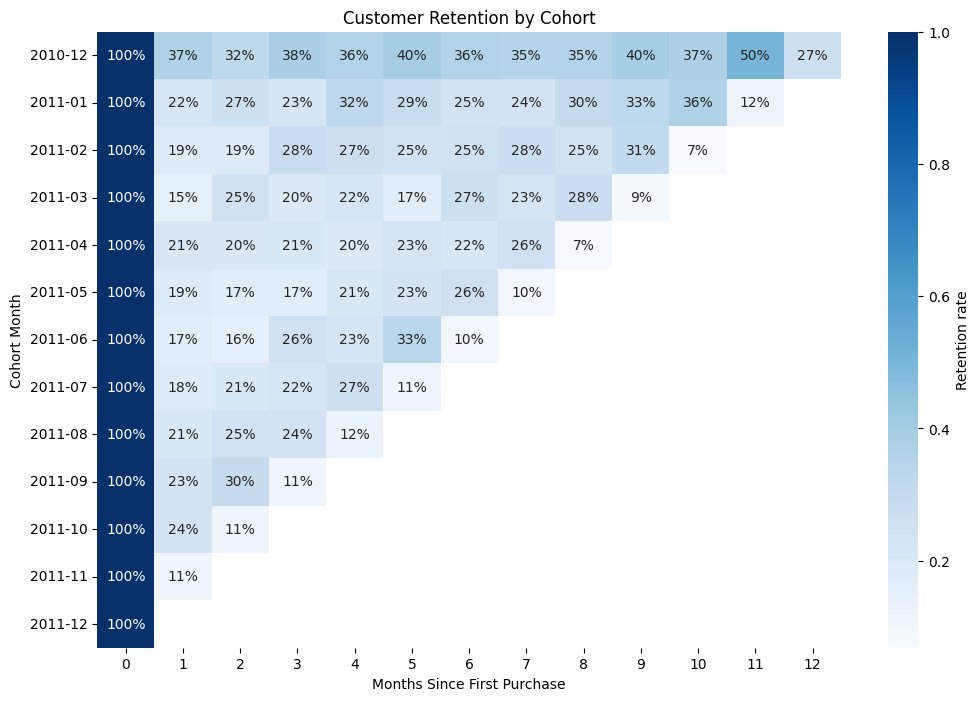

In [11]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    retention,
    annot=True,           # Add this line
    fmt='.0%',            # Add this line  
    cmap="Blues",
    cbar_kws={"label": "Retention rate"}
)

plt.title("Customer Retention by Cohort")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")
plt.show()

## Key observations

- Retention drops sharply after the first purchase month (typically to ~20-30%)
- Month-1 retention is relatively low, suggesting limited habitual repeat behaviour
- Later cohorts show similar decay patterns, indicating structural rather than cohort-specific effects

This suggests the business relies heavily on **new customer acquisition** rather than long-term customer retention.

## Project takeaway

This analysis demonstrates how cohort analysis can:
- separate acquisition-driven growth from retention-driven growth
- reveal customer behaviour patterns hidden in aggregate metrics

The same framework can be applied to:
- subscriptions
- SaaS usage
- loyalty programmes
- media or app engagement data
